# The minimal ring — a walkthrough

This notebook visualises **one specific model**: the 17-parameter ring attractor in
[`minimal_ring.py`](minimal_ring.py), fitted to the 77-cell AD population PSTH with the
antipode clamped silent (`_feas_global_0.5.json`, R² = 0.948).

**The question it answers.** Auditory stimulation of an AD head-direction cell at its
preferred direction produces a three-phase response: a **fast component (FC)**, an
**inhibitory dip**, and a **slow component (SC)**. At the antipode only the FC appears —
no SC. Where does that selectivity come from?

The hypothesis under test: *the SC input is spatially **uniform** — every cell gets it —
and the antipode is silent only because inhibition holds it below threshold.* No gating
variable, no NMDA/Mg block, no I_T, no I_h.

**The result this notebook shows.** It works. A basic ring with uniform inputs and
**global** inhibition reproduces the measured time course at 97% of the noise ceiling
while the antipode stays at exactly 0 Hz.

Written up in [MODEL_INHIBITION_ONLY.md](MODEL_INHIBITION_ONLY.md); caveats in
[OPEN_ISSUES.md](OPEN_ISSUES.md).

## The math

Two populations on a ring of $N = 120$ cells at angles $\theta_i \in [-\pi, \pi)$.
$\theta = 0$ is the preferred direction (PD), $\theta = \pi$ the antipode.

**Excitatory ring** — one equation per cell:

$$
\tau_E \frac{d u_E(\theta)}{dt} \;=\; -u_E(\theta)
\;+\; \underbrace{J_1 \,(K_E * r_E)(\theta)}_{\text{recurrent excitation}}
\;-\; \underbrace{W_{IE}\,(K_I * r_I)(\theta)}_{\text{interneuron ring}}
\;-\; \underbrace{W_{\text{global}} \,\langle r_E \rangle}_{\text{global inhibition}}
\;+\; \underbrace{I_{\text{base}} + I_{HD}\, h(\theta)}_{\text{tonic drive}}
\;+\; \underbrace{\mathrm{FC}(t) + \mathrm{SC}(t)}_{\text{stimulus, spatially uniform}}
$$

**Inhibitory population** — co-tuned, driven by the excitatory ring, and *slower*
($\tau_I$), which is what turns the FC overshoot into the dip:

$$
\tau_I \frac{d u_I(\theta)}{dt} \;=\; -u_I(\theta) + W_{EI}\,(K_E * r_E)(\theta)
$$

**Rates** — threshold-linear, no saturating nonlinearity:

$$
r_E = \mathrm{clip}\big(g\,[u_E]_+,\; 0,\; R_{\max}\big), \qquad r_I = [u_I]_+
$$

$R_{\max}$ is a **safety clip**, not a physiological ceiling — if a fit reaches it, that
fit has diverged and is rejected.

**Connectivity** — circular (von Mises) kernels, normalised by $N$. Narrow excitation
minus broad inhibition = Mexican hat:

$$
K_X(\Delta\theta) \;=\; \tfrac{1}{N}\,e^{\,\kappa_X\,(\cos \Delta\theta \,-\, 1)},
\qquad X \in \{E, I\}
$$

**Tonic HD drive** — the same shape, width fixed (not fitted), representing tuned input
inherited from the upstream lateral mammillary nucleus:

$$
h(\theta) = e^{\,\kappa_{HD}(\cos\theta - 1)}, \qquad \kappa_{HD} = 2
$$

**The two stimulus inputs — note there is no $\theta$ in either.** This is the whole
point: both are delivered identically to every cell on the ring.

$$
\mathrm{FC}(t) = A_{\text{fast}} \cdot \mathbb{1}\big[\,t_0 \le t < t_0 + d_{FC}\,\big],
\qquad t_0 = t_{\text{stim}} + \delta
$$

$$
\mathrm{SC}(t) = A_{sc}\Big(1 - e^{-(t - t_1)/\tau_{\text{on}}}\Big)\,
e^{-(t - t_1)/\tau_{\text{off}}}, \qquad t_1 = t_0 + \delta_{sc},\quad t \ge t_1
$$

### Why a uniform input can still produce a tuned output

Subtract the antipode's equation from the PD cell's:

$$
\frac{d(u_{PD} - u_{\text{anti}})}{dt} = -(u_{PD} - u_{\text{anti}})
\;+\; I_{HD}\,\Delta h \;+\; J_1 \Delta (K_E * r_E) \;-\; W_{IE}\,\Delta (K_I * r_I)
$$

Every **uniform** term — $I_{\text{base}}$, $W_{\text{global}}\langle r_E\rangle$, the FC
and the SC — enters both equations identically and **cancels exactly**. A uniform input
contributes *nothing* to the difference directly.

It acts **indirectly**. The recurrent term $J_1(K_E * r_E)$ depends on the rates, which the
uniform input raises — and that term is *tuned*, so lifting everyone raises the PD cell's
recurrent drive far more than the antipode's. The difference grows.

Selectivity therefore requires the antipode to stay at $u_{\text{anti}} < 0$ while
$u_{PD}$ climbs. That is what Figure 6 shows happening.

### Fixed constants (chosen, not fitted)

| symbol | value | why |
|---|---|---|
| $N$ | 120 | ring resolution, 3° per cell |
| $\Delta t$ | 0.2 ms | forward Euler step |
| $g$ (`GAIN_SLOPE`) | 6 Hz per unit $u$ | sets the $u \leftrightarrow$ Hz scale |
| $R_{\max}$ | 1000 Hz | divergence guard, never reached by a valid fit |
| $\kappa_{HD}$ | 2 | HD tuning width, ≈ 70–90° FWHM |

## Setup — load the fitted model and run it

In [1]:
import json, pathlib, sys
import numpy as np
import matplotlib.pyplot as plt

HERE = next(p for p in (pathlib.Path.cwd(), pathlib.Path.cwd() / "hdmodel")
            if (p / "minimal_ring.py").exists())
sys.path.insert(0, str(HERE))

import minimal_ring as mr
from vivo_target import load_target

plt.rcParams.update({"figure.figsize": (7.6, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
C_DATA, C_PD, C_ANTI = "0.15", "#2980b9", "#c0392b"
C_MODE = {"ring": "#c0392b", "global": "#2980b9", "both": "#27ae60"}

# The winning solution: global inhibition, anti-PD SC clamped below 0.5 Hz.
FIT = json.load(open(HERE / "_feas_global_0.5.json"))
MODE = FIT["mode"]
P = np.array([FIT["params"][k] for k in mr.PARAM_NAMES])

bins, rate, _ = load_target()          # AD dataset, 77 cells, population-mean PSTH
t, rates, u = mr.simulate(P, MODE, return_u=True)   # u = pre-rectification activation
pd_, anti = rates[:, mr.IDX_PD], rates[:, mr.IDX_ANTI]

w = (bins >= -50) & (bins <= 700)      # the fitting window
model_pd = np.interp(bins[w], t, pd_)
R2 = 1 - np.sum((rate[w] - model_pd) ** 2) / np.sum((rate[w] - rate[w].mean()) ** 2)
CEILING = 0.9726                       # bootstrap noise ceiling of the 77-cell mean

print(f"mode = {MODE} | {rates.shape[1]} cells x {rates.shape[0]} time steps")
print(f"R2 = {R2:.4f}   (noise ceiling {CEILING})")
print(f"data:  baseline {rate[(bins>=-50)&(bins<0)].mean():.1f} Hz | "
      f"FC peak {rate.max():.1f} Hz | SC peak {rate[(bins>40)&(bins<300)].max():.1f} Hz")

mode = global | 120 cells x 5500 time steps
R2 = 0.9477   (noise ceiling 0.9726)
data:  baseline 24.1 Hz | FC peak 161.8 Hz | SC peak 89.0 Hz


## The 17 parameters

Everything below was fitted. Grouped by what it controls:

- **network** (`tau_E`, `tau_I`, `J1`, `KAPPA_E`, `W_IE`, `KAPPA_I`, `W_EI`, `W_GLOBAL`) —
  the attractor itself,
- **tonic drive** (`I_baseline`, `I_HD`) — what holds the resting bump up,
- **stimulus** (`A_fast`, `fc_stim_duration`, `stim_delay`, `A_sc`, `tau_sc_on`,
  `tau_sc_off`, `sc_delay`) — the two uniform inputs.

The `inh_mode` switch zeroes whichever inhibition pathway an architecture turns off, so in
`global` mode the interneuron ring is inert — its parameters are shown as 0 below and carry
no meaning.

In [2]:
import pandas as pd

INFO = {
    "tau_E":            ("ms",       "excitatory membrane time constant"),
    "tau_I":            ("ms",       "inhibitory time constant — LAGS tau_E, which is what makes the dip"),
    "I_baseline":       ("u",        "uniform tonic drive to every cell"),
    "J1":               ("-",        "recurrent excitation gain — the only route to tuned amplification"),
    "KAPPA_E":          ("-",        "width of recurrent excitation (large = narrow)"),
    "W_IE":             ("-",        "interneuron -> excitatory weight (inhibition onto the ring)"),
    "KAPPA_I":          ("-",        "width of the inhibitory kernel (small = broad/near-uniform)"),
    "W_EI":             ("-",        "excitatory -> interneuron weight (drives the interneurons)"),
    "I_HD":             ("u",        "amplitude of the tuned tonic HD drive h(theta)"),
    "W_GLOBAL":         ("-",        "global inhibition gain, scales the population mean rate"),
    "A_fast":           ("u",        "FC pulse amplitude (uniform)"),
    "fc_stim_duration": ("ms",       "FC pulse width"),
    "stim_delay":       ("ms",       "sensory latency from stimulus onset to the FC"),
    "A_sc":             ("u",        "SC amplitude (uniform) — the hypothesis under test"),
    "tau_sc_on":        ("ms",       "SC rise time constant"),
    "tau_sc_off":       ("ms",       "SC decay time constant"),
    "sc_delay":         ("ms",       "SC onset relative to the FC"),
}

p_eff = mr.apply_inh_mode(P, MODE)     # what the simulation ACTUALLY used
pd.set_option("display.max_colwidth", 90)
pd.DataFrame({
    "parameter": mr.PARAM_NAMES,
    "fitted":    [f"{v:.3g}" for v in p_eff],
    "units":     [INFO[k][0] for k in mr.PARAM_NAMES],
    "meaning":   [INFO[k][1] for k in mr.PARAM_NAMES],
    "active":    ["-" if v == 0 and o != 0 else "yes" for v, o in zip(p_eff, P)],
}).set_index("parameter")

,fitted,units,meaning,active
parameter,,,,
tau_E,31.3,ms,excitatory membrane time constant,yes
tau_I,30,ms,"inhibitory time constant — LAGS tau_E, which is what makes the dip",yes
I_baseline,9.78,u,uniform tonic drive to every cell,yes
J1,0.263,-,recurrent excitation gain — the only route to tuned amplification,yes
KAPPA_E,23.6,-,width of recurrent excitation (large = narrow),yes
W_IE,0,-,interneuron -> excitatory weight (inhibition onto the ring),-
KAPPA_I,6.21,-,width of the inhibitory kernel (small = broad/near-uniform),yes
W_EI,0,-,excitatory -> interneuron weight (drives the interneurons),-
I_HD,11.3,u,amplitude of the tuned tonic HD drive h(theta),yes


## Figure 1 — does the model reproduce the measured response?

Model output at the PD cell against the 77-cell population mean, over the whole fitting
window. **What to look for:** all three phases present and in the right order — the FC
spike within ~10 ms, the dip below baseline at ~30 ms, the SC hump peaking near 70 ms, and
a slow decay that has *not* returned to baseline by 600 ms (neither has the data).

**Where it is honest:** the model undershoots the SC peak (~82% of the measured height) and
its dip is too shallow. R² = 0.948 sits *below* the 0.973 noise ceiling, which is the right
side of it — a fit above the ceiling would be fitting noise.

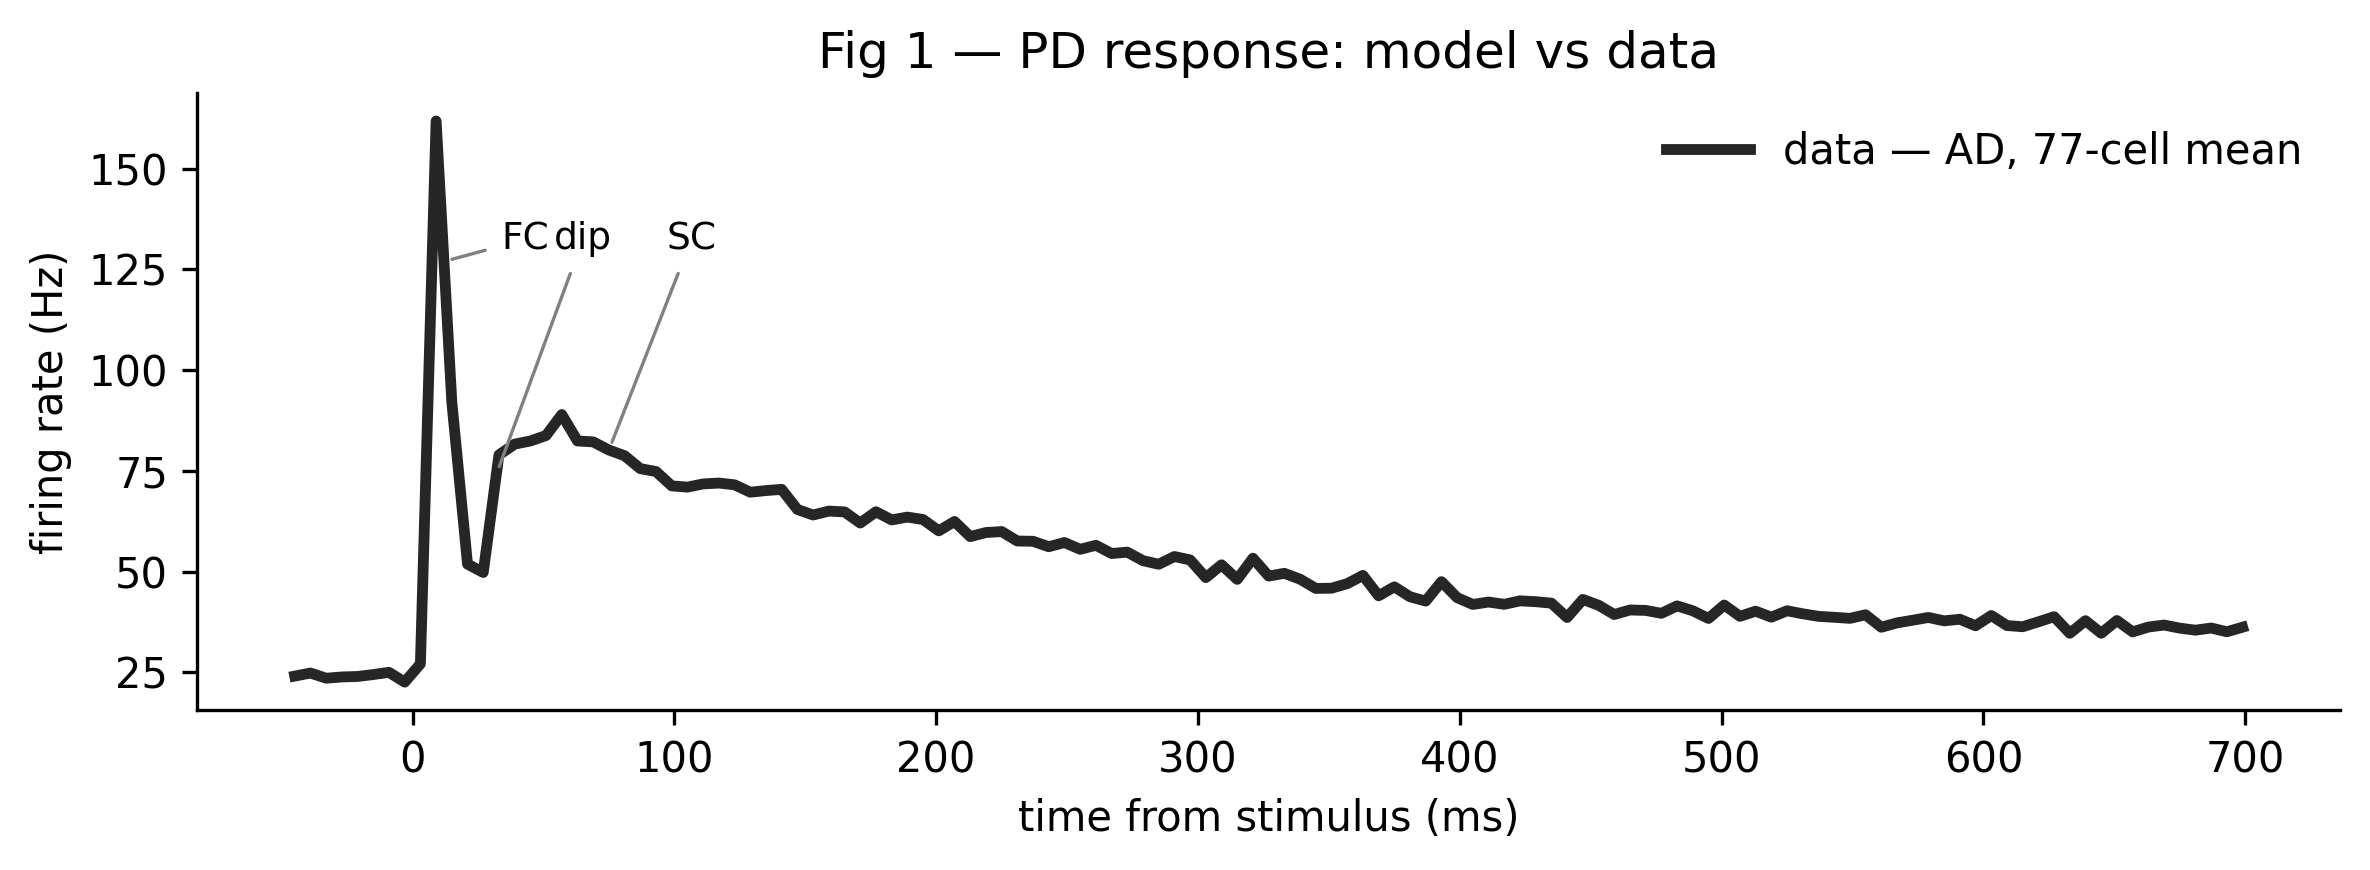

In [21]:
fig, ax = plt.subplots()
fig.set_dpi(300)
fig.set_size_inches((8,3))
ax.plot(bins[w], rate[w], color=C_DATA, lw=2.6, label="data — AD, 77-cell mean")
#ax.plot(bins[w], model_pd, color=C_PD, lw=2.0, label=f"model, PD cell  (R² = {R2:.3f})")
#ax.axvline(0, color="0.6", lw=1, ls=":")
#ax.axhline(rate[(bins >= -50) & (bins < 0)].mean(), color="0.7", lw=1, ls="--")

for x_, lab in [(12, "FC"), (32, "dip"), (75, "SC")]:
    ax.annotate(lab, xy=(x_, np.interp(x_, bins[w], rate[w])), xytext=(x_ + 22, 130),
                fontsize=9, arrowprops=dict(arrowstyle="-", color="0.5", lw=0.8))

ax.set_xlabel("time from stimulus (ms)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title("Fig 1 — PD response: model vs data")
ax.grid(False)
ax.legend(frameon=False)
fig.tight_layout()

## Figure 2 — the selectivity result

The same run, now showing the antipode as well. **What to look for:**

- the **FC reaches the antipode** (~74 Hz) — the input really is uniform, and the antipode
  is not unconditionally sub-threshold;
- the **SC does not** — anti-PD sits at exactly 0 Hz for the entire slow component.

That difference is produced by the network, not by anything in the input. There is no gate
in this model.

Note the antipode's silence is an **external constraint** (it comes from a different
dataset — this one is head-fixed with the cell always at PD, see
[DATA.md](DATA.md)); it enters here as a requirement the fit had to satisfy, not as data
being fitted.

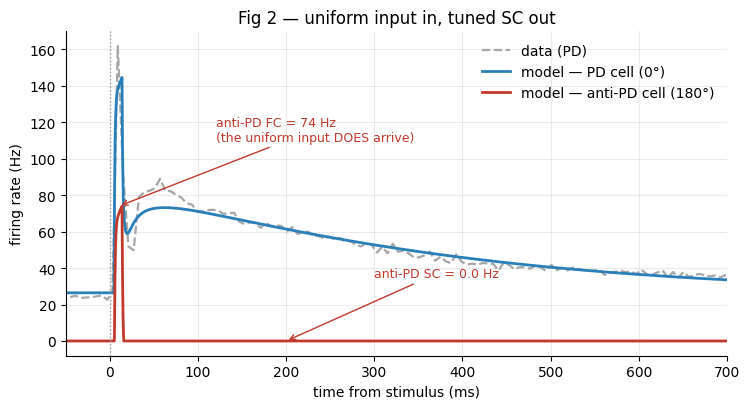

In [4]:
fig, ax = plt.subplots()
ax.plot(bins[w], rate[w], color="0.65", lw=1.6, ls="--", label="data (PD)")
ax.plot(t, pd_, color=C_PD, lw=2.0, label="model — PD cell (0°)")
ax.plot(t, anti, color=C_ANTI, lw=2.0, label="model — anti-PD cell (180°)")
ax.axvline(0, color="0.6", lw=1, ls=":")
ax.set_xlim(-50, 700)

m = mr.metrics(t, rates)
ax.annotate(f"anti-PD FC = {m['anti_fc']:.0f} Hz\n(the uniform input DOES arrive)",
            xy=(10, m["anti_fc"]), xytext=(120, 110), fontsize=9, color=C_ANTI,
            arrowprops=dict(arrowstyle="->", color=C_ANTI, lw=1))
ax.annotate(f"anti-PD SC = {m['anti_sc']:.1f} Hz", xy=(200, 0), xytext=(300, 35),
            fontsize=9, color=C_ANTI,
            arrowprops=dict(arrowstyle="->", color=C_ANTI, lw=1))

ax.set_xlabel("time from stimulus (ms)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title("Fig 2 — uniform input in, tuned SC out")
ax.legend(frameon=False)
fig.tight_layout()

## Figure 3 — the whole ring over the whole time course

All 120 cells (y) against time (x), colour = firing rate. This is the entire simulation in
one panel; every other figure is a slice through it.

**What to look for:** a stable bump at 0° before the stimulus; a bright vertical stripe at
t ≈ 5–15 ms — the FC, spanning *every* angle; a dark band right after it — the dip; then a
bump that grows in place during the SC and decays slowly. The bump never moves.

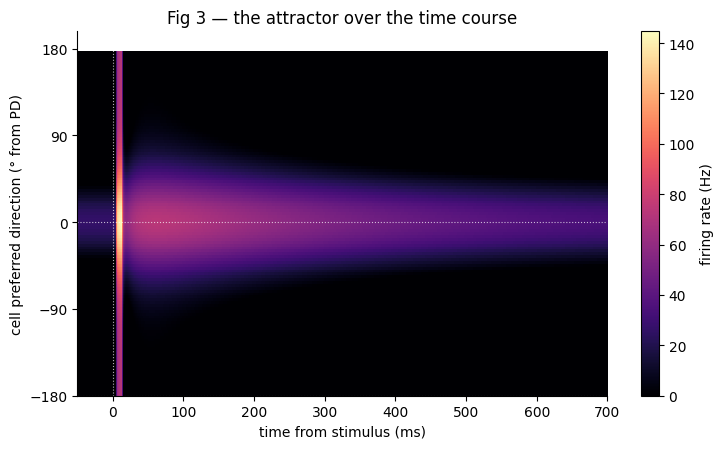

In [5]:
sel = (t >= -50) & (t <= 700)
deg = np.degrees(mr.THETA)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
im = ax.imshow(rates[sel].T, aspect="auto", origin="lower", cmap="magma",
               extent=[t[sel][0], t[sel][-1], deg[0], deg[-1]], interpolation="nearest")
ax.axhline(0, color="w", lw=0.8, ls=":", alpha=0.7)
ax.axhline(180, color="w", lw=0.8, ls=":", alpha=0.5)
ax.axhline(-180, color="w", lw=0.8, ls=":", alpha=0.5)
ax.axvline(0, color="w", lw=0.8, ls=":", alpha=0.7)
ax.set_yticks([-180, -90, 0, 90, 180])
ax.set_xlabel("time from stimulus (ms)")
ax.set_ylabel("cell preferred direction (° from PD)")
ax.set_title("Fig 3 — the attractor over the time course")
ax.grid(False)
fig.colorbar(im, ax=ax, label="firing rate (Hz)")
fig.tight_layout()

## Figure 4 — the whole population at single time points

Vertical slices through Figure 3: the firing rate of every cell at six moments.

**What to look for:** the FC (+10 ms) lifts the *entire ring*, including the antipode — a
pedestal, not a bump. Every other snapshot is a bump sitting on zero. So the SC's tuning is
not inherited from its input; the network makes it.

Right panel: the same curves with the y-axis clipped, so the flanks and the antipode are
readable next to the 145 Hz FC.

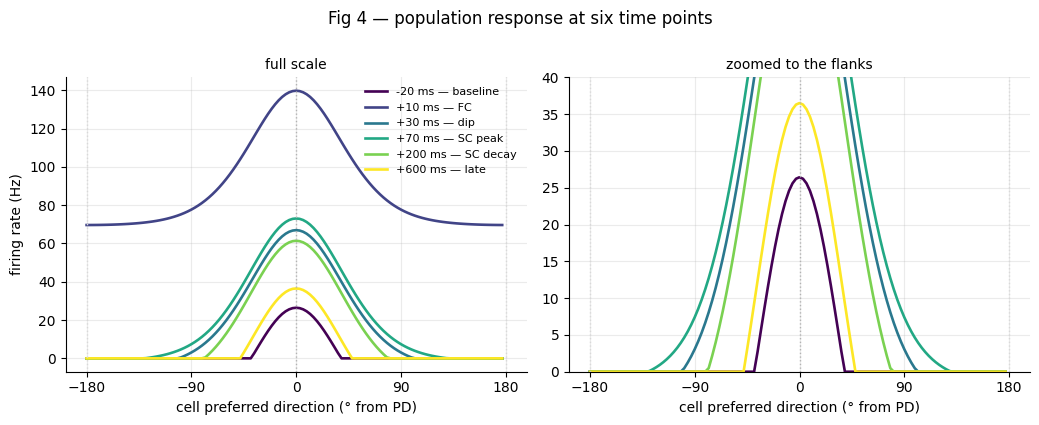

In [6]:
SNAPS = [(-20, "baseline"), (10, "FC"), (30, "dip"),
         (70, "SC peak"), (200, "SC decay"), (600, "late")]
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=True)
for ax, ymax, ttl in zip(axes, [None, 40], ["full scale", "zoomed to the flanks"]):
    for k, (ms, lab) in enumerate(SNAPS):
        i = int(np.argmin(np.abs(t - ms)))
        ax.plot(deg, rates[i], color=cmap(k / (len(SNAPS) - 1)), lw=1.9,
                label=f"{ms:+d} ms — {lab}")
    ax.axvline(0, color="0.7", lw=1, ls=":")
    ax.axvline(180, color="0.85", lw=1, ls=":")
    ax.axvline(-180, color="0.85", lw=1, ls=":")
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlabel("cell preferred direction (° from PD)")
    ax.set_title(ttl, fontsize=10)
    if ymax:
        ax.set_ylim(0, ymax)

axes[0].set_ylabel("firing rate (Hz)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Fig 4 — population response at six time points", y=1.0)
fig.tight_layout()

## Figure 5 — bump height and bump width, separately

Figure 3 summarised as two numbers per time step: the peak rate anywhere on the ring, and
the bump's FWHM in degrees.

**What to look for:** height and width move differently. The FC broadens the bump violently
(a uniform input has no width — the "FWHM" during the FC is meaningless and is greyed out),
while the SC raises the peak with the width *nearly unchanged*. That is the signature of
amplification inside the existing bump rather than a new, wider input.

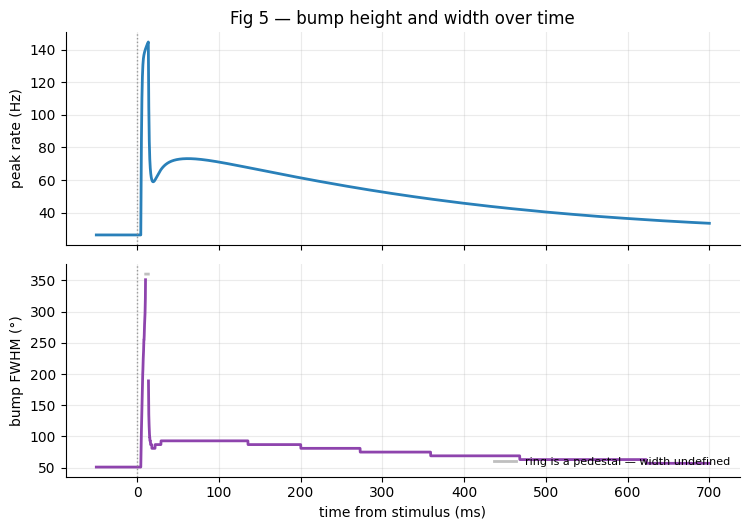

In [7]:
peak = rates.max(axis=1)
with np.errstate(invalid="ignore"):
    fwhm = (rates >= (peak[:, None] / 2)) .sum(axis=1) * 360.0 / mr.N
fwhm = np.where(peak > 1e-6, fwhm, np.nan)
pedestal = rates.min(axis=1) > 0.5 * peak      # uniform-ish -> "width" is not a bump width

fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.4), sharex=True)
axes[0].plot(t[sel], peak[sel], color=C_PD, lw=2)
axes[0].set_ylabel("peak rate (Hz)")
axes[0].set_title("Fig 5 — bump height and width over time")

axes[1].plot(t[sel], np.where(pedestal[sel], np.nan, fwhm[sel]), color="#8e44ad", lw=2)
axes[1].plot(t[sel], np.where(pedestal[sel], fwhm[sel], np.nan), color="0.75", lw=2,
             label="ring is a pedestal — width undefined")
axes[1].set_ylabel("bump FWHM (°)")
axes[1].set_xlabel("time from stimulus (ms)")
axes[1].legend(frameon=False, fontsize=8, loc="lower right")

for ax in axes:
    ax.axvline(0, color="0.6", lw=1, ls=":")
fig.tight_layout()

## Figure 6 — the mechanism: inhibition tracks the drive

This is the actual answer to "how does a uniform input become tuned".

**Top:** the uniform excitatory drive from the SC, against the global inhibition it causes,
$W_{\text{global}}\langle r_E\rangle$. Both are the *same* for every cell on the ring. As
the SC lifts the population, the mean rate rises, so global inhibition rises with it — it
**tracks and cancels** the SC.

**Bottom:** the consequence, in pre-rectification activation $u$. At the PD cell the tuned
drive $I_{HD}h(\theta)$ plus recurrent excitation keeps $u_{PD}$ well above the threshold at
0, so the SC shows. At the antipode there is no tuned term left and the cancellation is
close to exact, so $u_{\text{anti}}$ stays **below 0** and the SC is invisible.

This is a **normalisation**, and it is literally "the SC is gated by inhibition". Read
biologically it argues for a broadly-projecting inhibitory population (TRN-like) rather than
local Mexican-hat interneurons — which matches Figure 7, where the tuned interneuron ring
fails and the global pool succeeds.

**How close is the margin?** $u_{\text{anti}}$ peaks at about **−0.12** during the SC against
a $u_{PD}$ of ~+12 — the antipode clears threshold by roughly 1% of the PD activation, which
looks alarmingly tight. It isn't, because the cancellation is *graded*: the printout below
shows how far $u_{\text{anti}}$ sits from 0, not how fragile the silence is. Figure 10
measures the fragility directly, and it is mild.

during the SC (40-300 ms):  u_anti max = -0.12  (below 0 -> silent)   |   u_PD max = +12.20


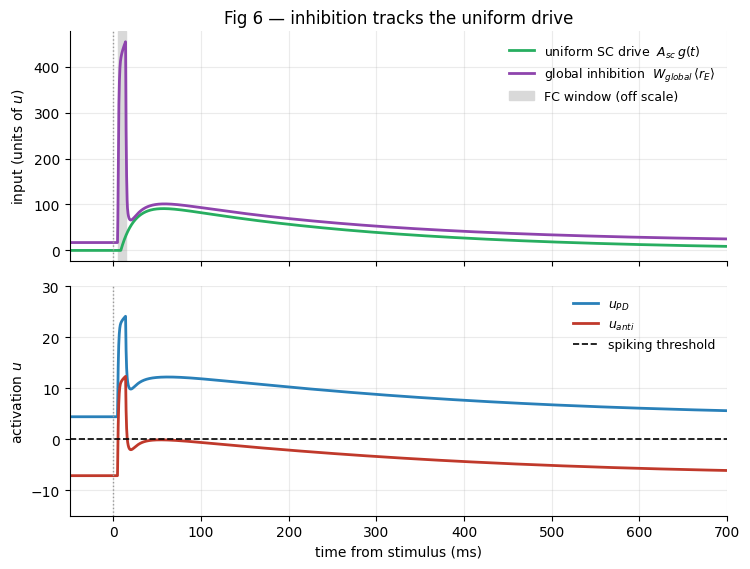

In [8]:
p = dict(zip(mr.PARAM_NAMES, p_eff))
fc_on = mr.T_STIM + p["stim_delay"]
fc_off = fc_on + p["fc_stim_duration"]
sc_on = fc_on + p["sc_delay"]

d = np.maximum(t - sc_on, 0.0)
sc_drive = np.where(t >= sc_on,
                    p["A_sc"] * (1 - np.exp(-d / p["tau_sc_on"])) * np.exp(-d / p["tau_sc_off"]),
                    0.0)
glob_inh = p["W_GLOBAL"] * rates.mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.8), sharex=True)

axes[0].plot(t, sc_drive, color="#27ae60", lw=2, label="uniform SC drive  $A_{sc}\\,g(t)$")
axes[0].plot(t, glob_inh, color="#8e44ad", lw=2,
             label="global inhibition  $W_{global}\\,\\langle r_E\\rangle$")
axes[0].axvspan(fc_on, fc_off, color="0.85", label="FC window (off scale)")
axes[0].set_ylabel("input (units of $u$)")
axes[0].set_title("Fig 6 — inhibition tracks the uniform drive")
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(t, u[:, mr.IDX_PD], color=C_PD, lw=2, label="$u_{PD}$")
axes[1].plot(t, u[:, mr.IDX_ANTI], color=C_ANTI, lw=2, label="$u_{anti}$")
axes[1].axhline(0, color="k", lw=1.2, ls="--", label="spiking threshold")
axes[1].set_ylim(-15, 30)
axes[1].set_ylabel("activation $u$")
axes[1].set_xlabel("time from stimulus (ms)")
axes[1].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.set_xlim(-50, 700)
    ax.axvline(0, color="0.6", lw=1, ls=":")
fig.tight_layout()

k = (t > 40) & (t < 300)
print(f"during the SC (40-300 ms):  u_anti max = {u[k, mr.IDX_ANTI].max():+.2f}  "
      f"(below 0 -> silent)   |   u_PD max = {u[k, mr.IDX_PD].max():+.2f}")

## Figure 7 — which kind of inhibition does the work?

Three architectures, each fitted independently with the antipode clamped silent:

| mode | interneuron ring | global pool |
|---|---|---|
| `ring` | on | off (`W_GLOBAL = 0`) |
| `global` | off (`W_IE = W_EI = 0`) | on |
| `both` | on | on |

**What to look for:** `ring` cannot fit the trace at all (R² is *negative* — worse than
predicting the mean). `global` succeeds. Adding the ring back on top of the global pool
(`both`) makes it worse.

So the result is specifically about **uniform inhibition proportional to total activity**,
not about Mexican-hat connectivity. That is a stronger and more falsifiable claim than "the
SC is gated by inhibition".

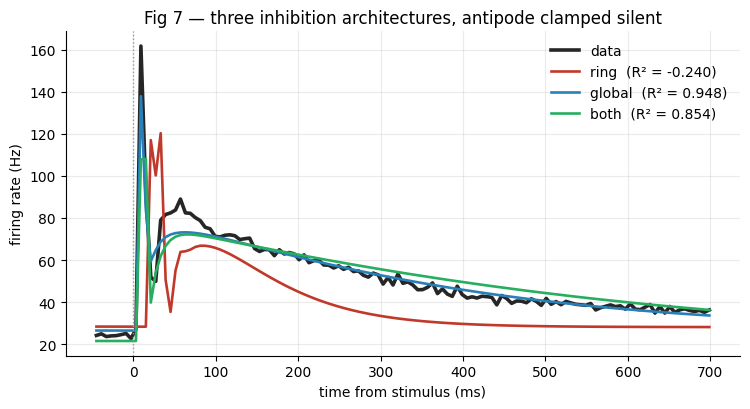

In [9]:
fig, ax = plt.subplots()
ax.plot(bins[w], rate[w], color=C_DATA, lw=2.6, label="data")
for mode in mr.INH_MODES:
    f = json.load(open(HERE / f"_feas_{mode}_0.5.json"))
    x = np.array([f["params"][k] for k in mr.PARAM_NAMES])
    tt, rr = mr.simulate(x, mode)
    ax.plot(bins[w], np.interp(bins[w], tt, rr[:, mr.IDX_PD]), color=C_MODE[mode], lw=1.9,
            label=f"{mode}  (R² = {f['r2']:.3f})")
ax.axvline(0, color="0.6", lw=1, ls=":")
ax.set_xlabel("time from stimulus (ms)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title("Fig 7 — three inhibition architectures, antipode clamped silent")
ax.legend(frameon=False)
fig.tight_layout()

## Figure 8 — what silencing the antipode costs

The falsification test. For each architecture, refit the PD trace while forbidding the
antipode's SC from exceeding a threshold, and sweep that threshold from 40 Hz down to
0.5 Hz. If forcing the antipode silent destroyed the fit, inhibition alone could not
account for the selectivity.

**What to look for:** the `global` curve is **flat**. Going from "antipode may do whatever
it likes" (40 Hz) to "antipode must be silent" (0.5 Hz) costs it 0.952 → 0.948 — nothing.
The prior expectation was that the SC could not reach its amplitude without the antipode
also rising out of the inhibitory lake. It can.

(Read from `probe_sc_feasibility.csv`; regenerate with `python probe_sc_feasibility.py`.)

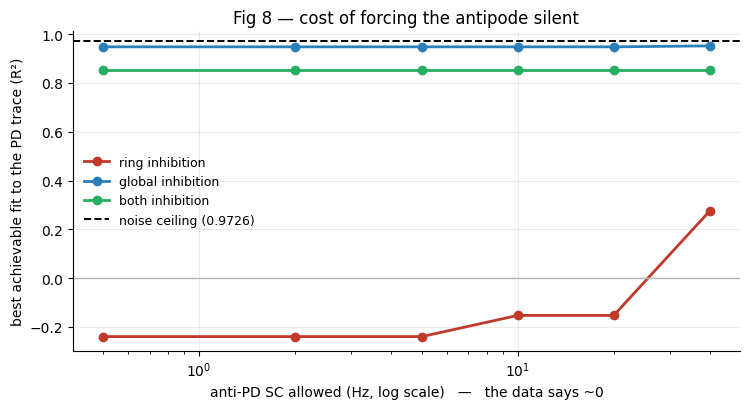

In [10]:
rows = [l.split(",") for l in (HERE / "probe_sc_feasibility.csv").read_text().splitlines()]
feas = [(r[1], float(r[2]), float(r[3])) for r in rows if r[0] == "feasibility"]

fig, ax = plt.subplots()
for mode in mr.INH_MODES:
    pts = sorted((thr, r2_) for mo, thr, r2_ in feas if mo == mode and np.isfinite(r2_))
    if pts:
        xs, ys = zip(*pts)
        ax.plot(xs, ys, "o-", color=C_MODE[mode], lw=2, label=f"{mode} inhibition")
ax.axhline(CEILING, color="k", ls="--", lw=1.4, label=f"noise ceiling ({CEILING})")
ax.axhline(0, color="0.7", lw=1)
ax.set_xscale("log")
ax.set_xlabel("anti-PD SC allowed (Hz, log scale)   —   the data says ~0")
ax.set_ylabel("best achievable fit to the PD trace (R²)")
ax.set_title("Fig 8 — cost of forcing the antipode silent")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

## Figure 9 — is this actually an attractor?

A continuous attractor maintains its bump *without* tuned input: remove the drive and the
recurrent connectivity should hold the bump where it is. Test it — set $I_{HD} = 0$, no
stimulus, and look at the resting state.

**What to look for:** the bump collapses. The fitted $J_1 = 0.26$ is almost no recurrent
excitation, so the tuning is **inherited** from $I_{HD}$, not maintained by the ring.

**This is not a quirk of the minimal model** — the original 32-parameter model fails the
same test (26.7 → 5.1 Hz). Calling either one "a ring attractor" overstates what the
recurrence does. It is consistent with the biology as stated (AD inherits HD tuning from the
lateral mammillary nucleus), but the Mexican hat is doing far less work than the name
implies. See [OPEN_ISSUES.md](OPEN_ISSUES.md) N2.

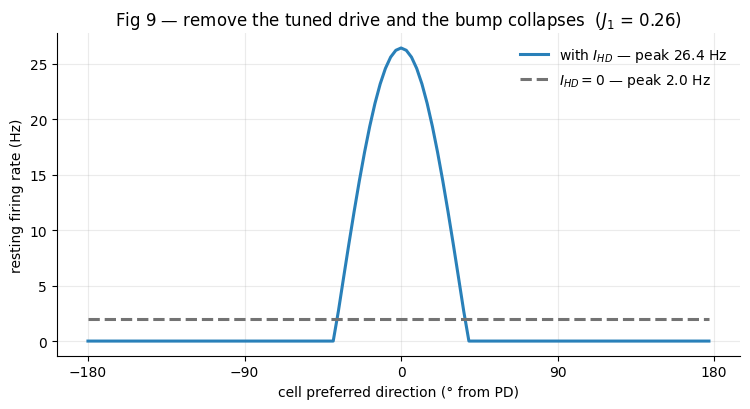

In [11]:
x_no = p_eff.copy()
x_no[mr.PARAM_NAMES.index("I_HD")] = 0.0

_, r_with = mr.simulate(p_eff, MODE, with_fc=False, with_sc=False)
_, r_without = mr.simulate(x_no, MODE, with_fc=False, with_sc=False)

fig, ax = plt.subplots()
ax.plot(deg, r_with[-1], color=C_PD, lw=2.2,
        label=f"with $I_{{HD}}$ — peak {r_with[-1].max():.1f} Hz")
ax.plot(deg, r_without[-1], color="0.45", lw=2.2, ls="--",
        label=f"$I_{{HD}} = 0$ — peak {r_without[-1].max():.1f} Hz")
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_xlabel("cell preferred direction (° from PD)")
ax.set_ylabel("resting firing rate (Hz)")
ax.set_title(f"Fig 9 — remove the tuned drive and the bump collapses  ($J_1$ = {p['J1']:.2f})")
ax.legend(frameon=False)
fig.tight_layout()

## Figure 10 — does the mechanism need fine tuning?

The obvious objection to a cancellation mechanism is that it must be *tuned* to cancel. So
scale the global inhibition gain $W_{\text{global}}$ around its fitted value, change
**nothing else**, and watch the antipode and the fit.

**What to look for — the two curves behave very differently:**

- **Silence has no upper cliff.** At the fitted gain and anywhere *above* it, the antipode's
  SC is exactly 0 Hz. Over-inhibiting cannot break the selectivity; there is no fine-tuning
  requirement in that direction at all.
- **Below it the leak is graded and small.** 15% weaker inhibition leaks ~2.8 Hz — against a
  PD SC of ~73 Hz. The antipode degrades gently, it does not switch on.
- **Fit quality is the sensitive quantity, and only mildly**: ±10% costs ~0.03 R².

So the mechanism does *not* balance on a knife edge, which is the answer to the natural
objection. What it does need is for the inhibition to be strong *enough* — a lower bound,
not a set point.

One honest note: R² actually peaks slightly *off* the fitted value (~0.950 at 0.975×, with
the antipode still exactly silent). The constrained optimiser left a little on the table.

W_global x 0.85 -> anti-PD SC  2.78 Hz | R2 0.9163
W_global x 0.90 -> anti-PD SC  1.49 Hz | R2 0.9402
W_global x 0.95 -> anti-PD SC  0.36 Hz | R2 0.9500
W_global x 1.00 -> anti-PD SC  0.00 Hz | R2 0.9477
W_global x 1.05 -> anti-PD SC  0.00 Hz | R2 0.9349
W_global x 1.15 -> anti-PD SC  0.00 Hz | R2 0.8858


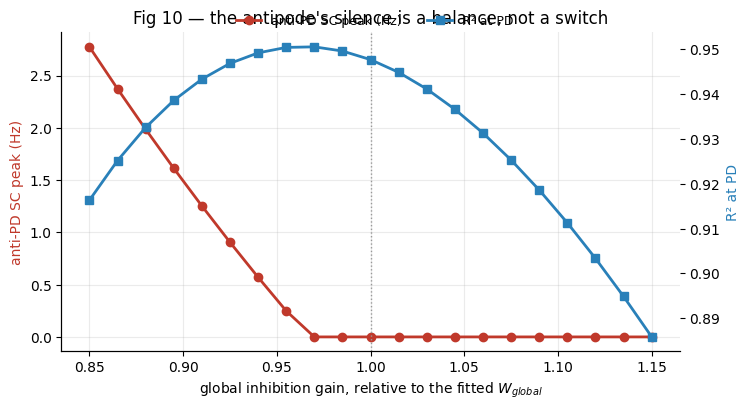

In [12]:
i_wg = mr.PARAM_NAMES.index("W_GLOBAL")
scales = np.linspace(0.85, 1.15, 21)
leak, fits = [], []
for s in scales:
    x = p_eff.copy()
    x[i_wg] = p_eff[i_wg] * s
    tt, rr = mr.simulate(x, MODE)
    leak.append(mr.metrics(tt, rr)["anti_sc"])
    mv = np.interp(bins[w], tt, rr[:, mr.IDX_PD])
    fits.append(1 - np.sum((rate[w] - mv) ** 2) / np.sum((rate[w] - rate[w].mean()) ** 2))

fig, ax = plt.subplots()
ax.plot(scales, leak, "o-", color=C_ANTI, lw=2, label="anti-PD SC peak (Hz)")
ax.set_xlabel("global inhibition gain, relative to the fitted $W_{global}$")
ax.set_ylabel("anti-PD SC peak (Hz)", color=C_ANTI)
ax.axvline(1.0, color="0.6", lw=1, ls=":")

ax2 = ax.twinx()
ax2.plot(scales, fits, "s-", color=C_PD, lw=2, label="R² at PD")
ax2.set_ylabel("R² at PD", color=C_PD)
ax2.grid(False)

ax.set_title("Fig 10 — the antipode's silence is a balance, not a switch")
fig.legend(frameon=False, fontsize=9, loc="upper center", ncols=2, bbox_to_anchor=(0.5, 0.98))
fig.tight_layout()

for s in (0.85, 0.90, 0.95, 1.00, 1.05, 1.15):
    print(f"W_global x {s:.2f} -> anti-PD SC {np.interp(s, scales, leak):5.2f} Hz | "
          f"R2 {np.interp(s, scales, fits):.4f}")

## What this notebook does and does not establish

**Does:**

- A ring with **spatially uniform** auditory inputs and **global** inhibition reproduces the
  measured FC → dip → SC time course at PD (R² 0.948 vs a 0.973 ceiling).
- It does so with the antipode at **exactly 0 Hz** through the SC, at essentially no cost in
  fit quality — so no gating variable (I_T, I_h, NMDA/Mg block, bump-membership gate) is
  *required* to explain the selectivity.
- The mechanism is identifiable and simple: global inhibition tracks the uniform drive and
  cancels it wherever there is no tuned excitation.

**Does not:**

- **Prove the brain does this.** This is a sufficiency result. The gated models also fit;
  showing one mechanism suffices does not exclude the others.
- **Validate out of sample.** R² is in-sample against the full 77-cell mean; no
  cross-validation has been run on this model. It sits *below* the noise ceiling, which
  argues against noise-fitting, but that is not the same as a CV score.
- **Test direction-selectivity against data.** This dataset is head-fixed with the cell
  always at PD ([DATA.md](DATA.md)). The antipode's behaviour is an external constraint
  imported from a different dataset, imposed here as a fitting requirement.
- **Justify the word "attractor"** — see Figure 9.

One objection it *does* answer: the mechanism does not require fine tuning. The antipode is
exactly silent at the fitted inhibition gain and at every stronger one, and leaks only ~2.8 Hz
at 15% weaker (Figure 10). "Inhibition strong enough" is a lower bound, not a set point.

17 free parameters against ~18 effectively independent time points remains the standing
over-parameterisation problem ([OPEN_ISSUES.md](OPEN_ISSUES.md) A1); it applies to every
model in this repo.